# Compiled Beam: Region Visualization

Static analysis of FST structure for compiled decomposition. Each FST's states are classified into regions:

- **Hub** (green): IP-universal + final + output-deterministic. Scoring via trie-mass sparse matvec.
- **Corridor** (blue): Deterministic chains, powerset stays size 1. (Analysis-only for now.)
- **Plateau** (orange): All-IP-universal subgraph. (Analysis-only for now.)
- **Wild** (red): General fallback, full BFS decomposition.

In [1]:
import numpy as np
from IPython.display import display, HTML

from transduction import examples, FST
from transduction.fst import EPSILON
from transduction.lm.base import LM, LMState
from transduction.util import LogDistr
from transduction.lm.compiled_beam import (
    CompiledBeam, RegionAnalyzer, RegionMap,
    render_region_map_html, render_region_graphviz,
)

class TinyState(LMState):
    def __init__(self, probs, logprefix=0.0):
        self._probs = probs
        self.logprefix = logprefix
    @property
    def logp_next(self):
        return LogDistr(self._probs)
    @property
    def eos(self):
        return '<EOS>'
    def __rshift__(self, token):
        lp = self._probs.get(token, -np.inf)
        return TinyState(self._probs, self.logprefix + lp)

class TinyLM(LM):
    def __init__(self):
        self.eos = '<EOS>'
    def initial(self):
        return TinyState({'a': np.log(0.6), 'b': np.log(0.3), '<EOS>': np.log(0.1)})

def copy_fst(alphabet):
    fst = FST()
    fst.add_start(0)
    fst.add_stop(0)
    for x in alphabet:
        fst.add_arc(0, x, x, 0)
    return fst

inner_lm = TinyLM()

In [2]:
def show_fst(name, fst):
    """Show region analysis + colored graph for one FST."""
    rmap = RegionAnalyzer(fst, inner_lm).analyze()
    display(HTML(f'<h2 style="margin-top:24px;">{name}</h2>'))
    display(HTML(render_region_map_html(rmap, fst)))
    g = render_region_graphviz(fst, rmap)
    display(g)

## Pure Hub FSTs
These are fully covered by hub regions — no wild fallback needed.

State,Region,Details
0,Hub,"2 tokens, 5 trie nodes"


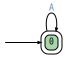

State,Region,Details
0,Hub,"53 tokens, 81 trie nodes"


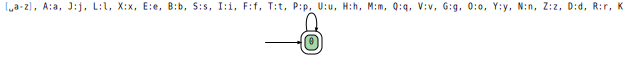

State,Region,Details
0,Hub,"2 tokens, 4 trie nodes"


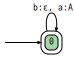

State,Region,Details
0,Hub,"53 tokens, 107 trie nodes"


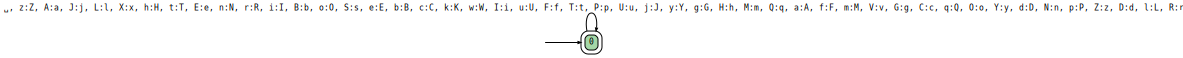

In [3]:
show_fst("copy_ab", copy_fst(['a', 'b']))
show_fst("lowercase", examples.lowercase())
show_fst("delete_b", examples.delete_b())
show_fst("togglecase", examples.togglecase())

## Multi-Hub FSTs
Multiple hub states, each with its own trie-mass scoring region.

State,Region,Details
h0,Hub,"2 tokens, 5 trie nodes"
h1,Hub,"2 tokens, 5 trie nodes"


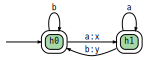

State,Region,Details
0,Hub,"2 tokens, 5 trie nodes"
1,Hub,"2 tokens, 5 trie nodes"
2,Hub,"2 tokens, 5 trie nodes"


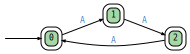

State,Region,Details
0,Hub,"2 tokens, 5 trie nodes"
1,Hub,"2 tokens, 5 trie nodes"
2,Hub,"2 tokens, 5 trie nodes"
3,Hub,"2 tokens, 5 trie nodes"
4,Hub,"2 tokens, 5 trie nodes"


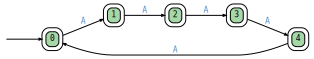

In [4]:
show_fst("two_hub_alternating", examples.two_hub_alternating())
show_fst("multi_hub_chain(3)", examples.multi_hub_chain(n=3))
show_fst("multi_hub_chain(5)", examples.multi_hub_chain(n=5))

## Mixed FSTs (Hub + Wild)
Some states are hubs, others require general BFS fallback.

State,Region,Details
3,Hub,"2 tokens, 5 trie nodes"
0,Corridor,2 deterministic arcs
2,Corridor,2 deterministic arcs


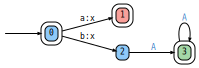

State,Region,Details
E,Hub,"2 tokens, 5 trie nodes"
root,Hub,"2 tokens, 5 trie nodes"
C,Corridor,2 deterministic arcs
D,Corridor,1 deterministic arcs


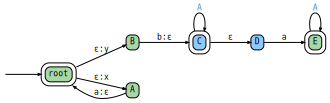

State,Region,Details
0,Hub,"2 tokens, 5 trie nodes"
1,Plateau,IP-universal
2,Plateau,IP-universal


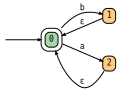

In [5]:
show_fst("small", examples.small())
show_fst("hub_with_escape", examples.hub_with_escape())
show_fst("weird_copy", examples.weird_copy())

## No-Hub FSTs (Wild + Corridors)
No hub states detected — everything falls back to wild scoring. Corridors appear in analysis only.

State,Region,Details
0,Corridor,1 deterministic arcs
1,Corridor,1 deterministic arcs


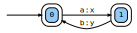

State,Region,Details
0,Corridor,2 deterministic arcs
1,Corridor,1 deterministic arcs
2,Corridor,1 deterministic arcs
3,Corridor,1 deterministic arcs
4,Corridor,1 deterministic arcs


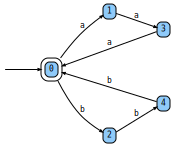

State,Region,Details
1,Corridor,1 deterministic arcs
3,Corridor,1 deterministic arcs


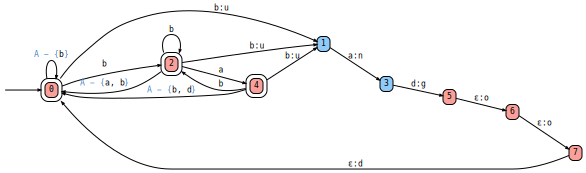

In [6]:
show_fst("no_hub_transducer", examples.no_hub_transducer())
show_fst("triplets_of_doom", examples.triplets_of_doom())
show_fst("newspeak2", examples.newspeak2())

## BPE-like FSTs (Scaling)
Single hub covering the entire FST. Trie size grows with vocab.

State,Region,Details
(),Hub,"10 tokens, 21 trie nodes"


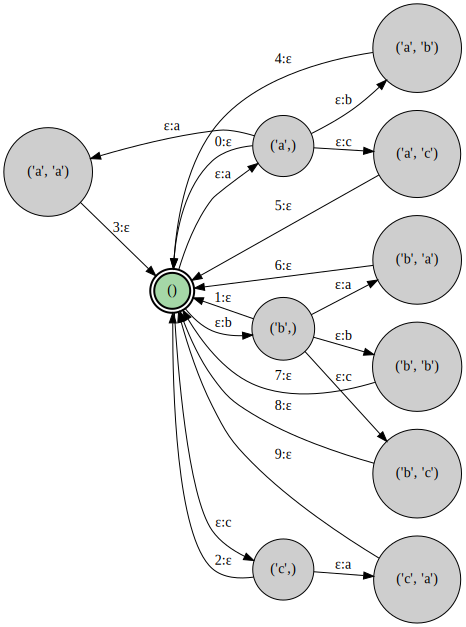

State,Region,Details
(),Hub,"20 tokens, 41 trie nodes"


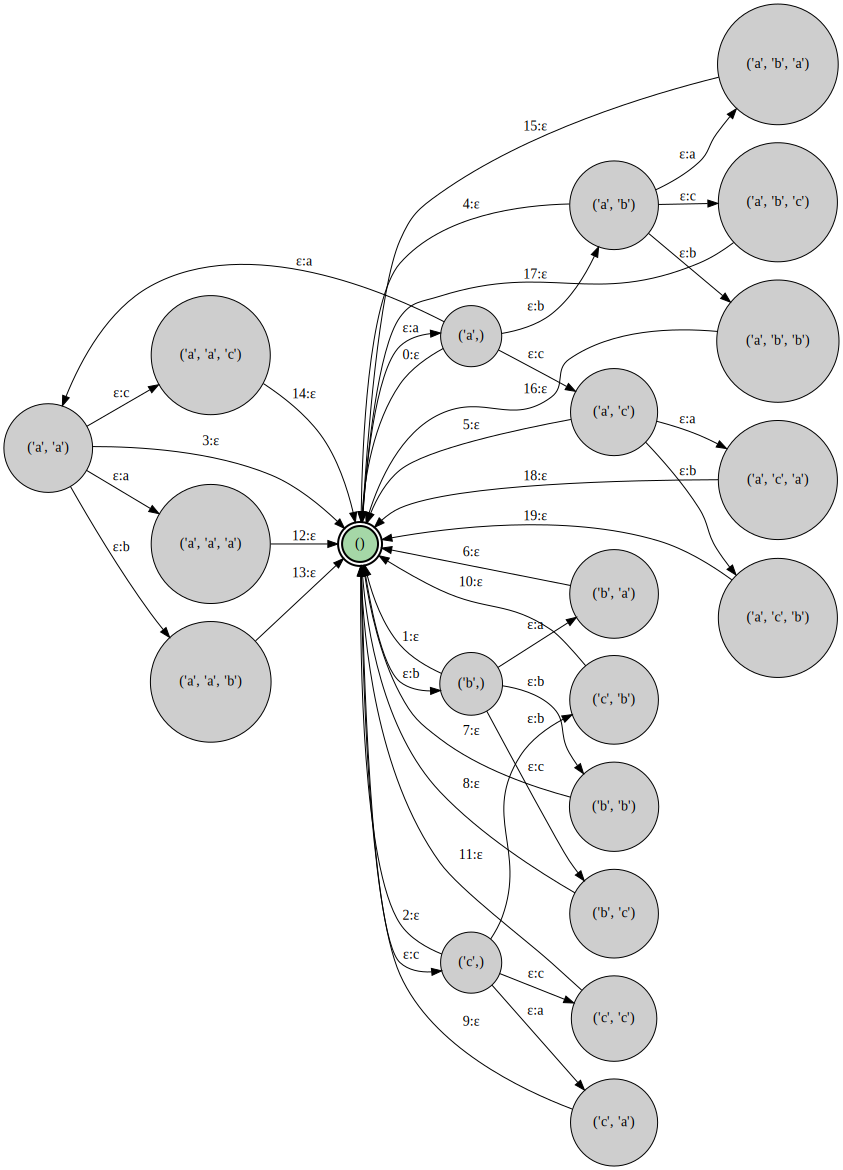

State,Region,Details
(),Hub,"50 tokens, 101 trie nodes"


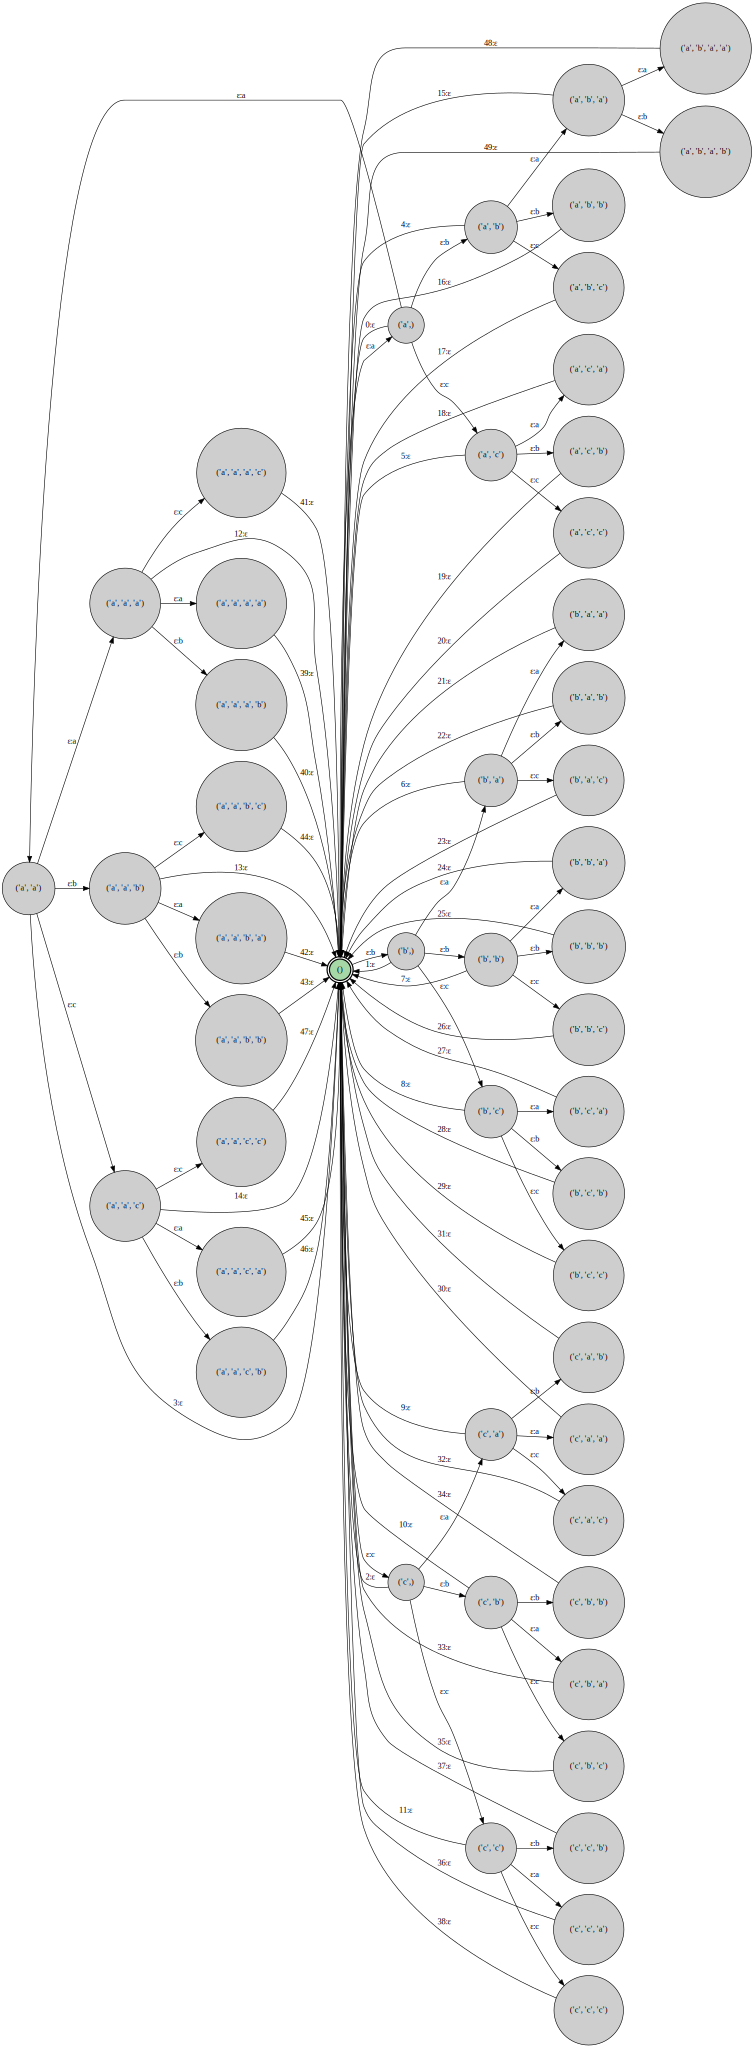

In [7]:
show_fst("bpe_like(10)", examples.bpe_like(vocab_size=10))
show_fst("bpe_like(20)", examples.bpe_like(vocab_size=20))
show_fst("bpe_like(50)", examples.bpe_like(vocab_size=50))

## Summary Table

In [8]:
ALL_FSTS = [
    ("copy_ab",           lambda: copy_fst(['a', 'b'])),
    ("small",             examples.small),
    ("lowercase",         examples.lowercase),
    ("delete_b",          examples.delete_b),
    ("triplets_of_doom",  examples.triplets_of_doom),
    ("two_hub_alt",       examples.two_hub_alternating),
    ("hub_with_escape",   examples.hub_with_escape),
    ("multi_hub_chain_3", lambda: examples.multi_hub_chain(n=3)),
    ("multi_hub_chain_5", lambda: examples.multi_hub_chain(n=5)),
    ("no_hub",            examples.no_hub_transducer),
    ("bpe_like_10",       lambda: examples.bpe_like(vocab_size=10)),
    ("bpe_like_50",       lambda: examples.bpe_like(vocab_size=50)),
    ("bpe_like_200",      lambda: examples.bpe_like(vocab_size=200)),
    ("weird_copy",        examples.weird_copy),
    ("togglecase",        examples.togglecase),
    ("newspeak2",         examples.newspeak2),
]

rows = []
for name, fst_fn in ALL_FSTS:
    fst = fst_fn()
    rmap = RegionAnalyzer(fst, inner_lm).analyze()
    n_states = len(fst.states)
    n_arcs = sum(len(fst.arcs(s)) for s in fst.states)
    n_hubs = len(rmap.hub_regions)
    n_corridors = len(rmap.corridor_regions)
    n_plateaus = len(rmap.plateau_regions)
    has_wild = 'Y' if rmap.wild_region is not None else 'N'
    hub_tokens = sum(len(r.trie._source_syms) for r in rmap.hub_regions.values())
    rows.append((name, n_states, n_arcs, n_hubs, n_corridors, n_plateaus, has_wild, hub_tokens))

html = ['<table style="border-collapse:collapse; font-family:monospace; font-size:13px;">']
html.append('<tr style="border-bottom:2px solid #333; font-weight:bold;">')
for h in ['FST', 'States', 'Arcs', 'Hubs', 'Corridors', 'Plateaus', 'Wild', 'Hub Tokens']:
    html.append(f'<th style="padding:4px 10px; text-align:right;">{h}</th>')
html.append('</tr>')
for row in rows:
    html.append('<tr style="border-bottom:1px solid #ddd;">')
    html.append(f'<td style="padding:3px 10px; text-align:left; font-weight:bold;">{row[0]}</td>')
    for v in row[1:]:
        html.append(f'<td style="padding:3px 10px; text-align:right;">{v}</td>')
    html.append('</tr>')
html.append('</table>')
display(HTML('\n'.join(html)))

FST,States,Arcs,Hubs,Corridors,Plateaus,Wild,Hub Tokens
copy_ab,1,2,1,0,0,N,2
small,4,6,1,2,0,Y,2
lowercase,1,53,1,0,0,N,53
delete_b,1,2,1,0,0,N,2
triplets_of_doom,5,6,0,5,0,Y,0
two_hub_alt,2,4,2,0,0,N,4
hub_with_escape,6,10,2,4,0,Y,4
multi_hub_chain_3,3,6,3,0,0,N,6
multi_hub_chain_5,5,10,5,0,0,N,10
no_hub,2,2,0,2,0,Y,0
